In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime

# Load data
df = pd.read_csv("customer_data.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())

# --- Feature Engineering ---

# Convert Last Purchase Date to days since last purchase
df['Last Purchase Date'] = pd.to_datetime(df['Last Purchase Date'])
today = datetime.today()
df['Days Since Purchase'] = (today - df['Last Purchase Date']).dt.days

# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# Encode City
df['City_Encoded'] = le.fit_transform(df['City'])

# Select features for modeling
features = ['Age', 'Gender_Encoded', 'City_Encoded', 'Purchase Amount ($)', 'Days Since Purchase']
X = df[features].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures selected:", features)
print("Scaled data shape:", X_scaled.shape)
print("\nPreprocessing complete! ✅")

Shape: (15, 9)

First 5 rows:
   Customer ID         Name  Age  Gender       City               Email  \
0            1     Ali Khan   28    Male    Karachi     ali@example.com   
1            2   Sara Ahmed   24  Female     Lahore    sara@example.com   
2            3    Usman Ali   35    Male  Islamabad   usman@example.com   
3            4  Ayesha Noor   30  Female   Peshawar  ayesha@example.com   
4            5  Hassan Raza   40    Male     Quetta  hassan@example.com   

        Phone  Purchase Amount ($) Last Purchase Date  
0  3001234567                  250         2026-06-01  
1  3011234567                  180         2026-05-28  
2  3121234567                  420         2026-05-20  
3  3331234567                  150         2026-06-03  
4  3451234567                  600         2026-04-15  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               ------

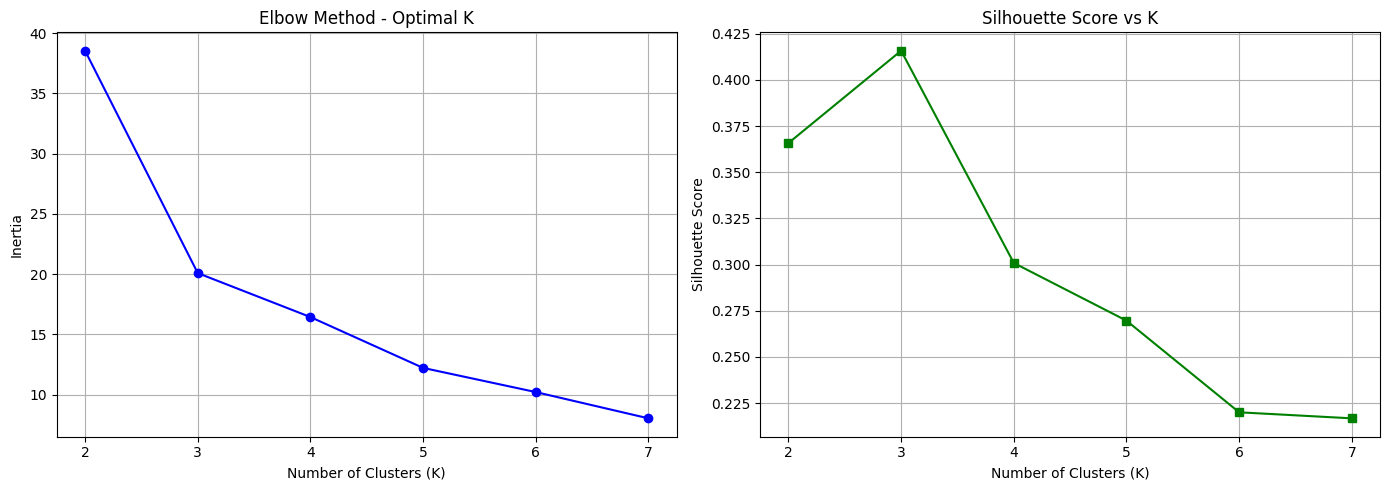

Elbow & Silhouette plots saved ✅

📊 K-Means Cluster Summary:
                  Age  Purchase Amount ($)  Days Since Purchase
KMeans_Cluster                                                 
0               33.00               365.83                26.83
1               26.14               208.57                 8.71
2               42.50               675.00                71.00


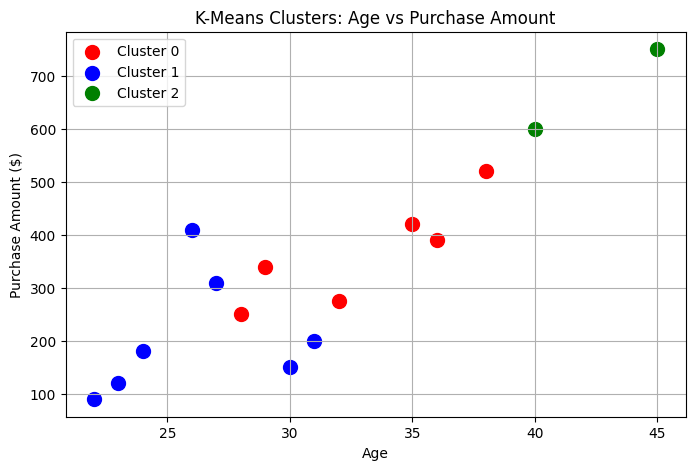

Cluster plot saved ✅

K-Means Clustering Complete! ✅


In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Find Optimal K using Elbow Method ---
inertia = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()
print("Elbow & Silhouette plots saved ✅")

# --- Apply K-Means with Best K ---
best_k = 3  # Change this based on your elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# --- Cluster Summary ---
print("\n📊 K-Means Cluster Summary:")
print(df.groupby('KMeans_Cluster')[['Age', 'Purchase Amount ($)', 'Days Since Purchase']].mean().round(2))

# --- Visualize Clusters (Age vs Purchase Amount) ---
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green']
for cluster in range(best_k):
    subset = df[df['KMeans_Cluster'] == cluster]
    plt.scatter(subset['Age'], subset['Purchase Amount ($)'],
                label=f'Cluster {cluster}', s=100, color=colors[cluster])

plt.title('K-Means Clusters: Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount ($)')
plt.legend()
plt.grid(True)
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()
print("Cluster plot saved ✅")
print("\nK-Means Clustering Complete! ✅")

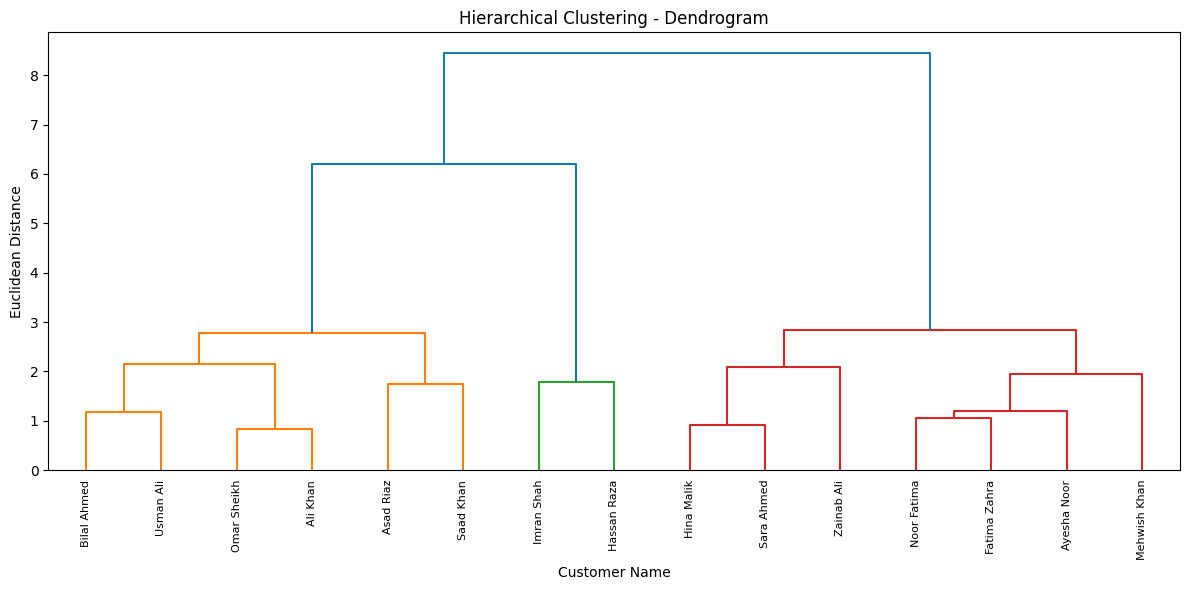

Dendrogram saved ✅

📊 Silhouette Score (Hierarchical): 0.4158

📊 Hierarchical Cluster Summary:
              Age  Purchase Amount ($)  Days Since Purchase
HC_Cluster                                                 
0           26.14               208.57                 8.71
1           33.00               365.83                26.83
2           42.50               675.00                71.00


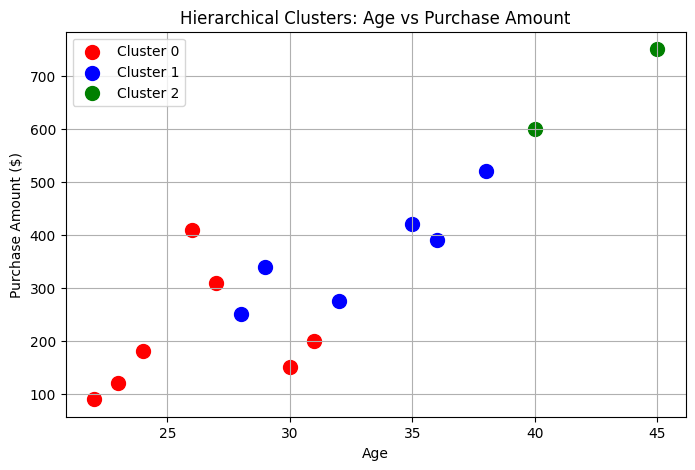

Hierarchical Cluster plot saved ✅

🔍 Cluster Comparison (KMeans vs Hierarchical):
            Name  Age  Purchase Amount ($)  KMeans_Cluster  HC_Cluster
0       Ali Khan   28                  250               0           1
1     Sara Ahmed   24                  180               1           0
2      Usman Ali   35                  420               0           1
3    Ayesha Noor   30                  150               1           0
4    Hassan Raza   40                  600               2           2
5   Fatima Zahra   27                  310               1           0
6    Bilal Ahmed   32                  275               0           1
7     Hina Malik   22                   90               1           0
8    Omar Sheikh   29                  340               0           1
9     Zainab Ali   26                  410               1           0
10     Saad Khan   38                  520               0           1
11   Noor Fatima   31                  200               1        

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# --- Step 1: Plot Dendrogram to find optimal clusters ---
plt.figure(figsize=(12, 6))

linked = linkage(X_scaled, method='ward')

dendrogram(
    linked,
    labels=df['Name'].values,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title('Hierarchical Clustering - Dendrogram')
plt.xlabel('Customer Name')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150)
plt.show()
print("Dendrogram saved ✅")

# --- Step 2: Apply Agglomerative Clustering ---
best_k = 3  # Adjust based on dendrogram cut

hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['HC_Cluster'] = hc.fit_predict(X_scaled)

# Silhouette Score
score = silhouette_score(X_scaled, df['HC_Cluster'])
print(f"\n📊 Silhouette Score (Hierarchical): {score:.4f}")

# --- Step 3: Cluster Summary ---
print("\n📊 Hierarchical Cluster Summary:")
print(df.groupby('HC_Cluster')[['Age', 'Purchase Amount ($)', 'Days Since Purchase']].mean().round(2))

# --- Step 4: Visualize Clusters ---
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green']

for cluster in range(best_k):
    subset = df[df['HC_Cluster'] == cluster]
    plt.scatter(subset['Age'], subset['Purchase Amount ($)'],
                label=f'Cluster {cluster}', s=100, color=colors[cluster])

plt.title('Hierarchical Clusters: Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount ($)')
plt.legend()
plt.grid(True)
plt.savefig('hierarchical_clusters.png', dpi=150)
plt.show()
print("Hierarchical Cluster plot saved ✅")

# --- Step 5: Compare K-Means vs Hierarchical ---
print("\n🔍 Cluster Comparison (KMeans vs Hierarchical):")
print(df[['Name', 'Age', 'Purchase Amount ($)', 'KMeans_Cluster', 'HC_Cluster']])

print("\nHierarchical Clustering Complete! ✅")

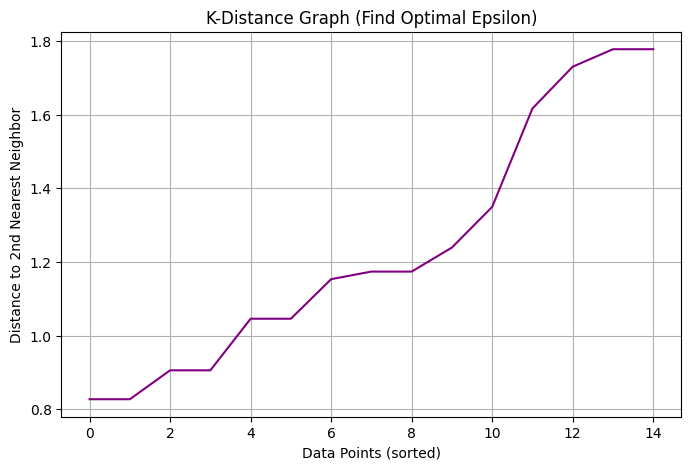

K-Distance graph saved ✅
👉 Look at the 'elbow point' in the graph — that is your best epsilon value

📊 DBSCAN Results:
   ✅ Number of Clusters Found : 2
   ⚠️  Noise Points (Outliers)  : 11
   📈 Silhouette Score         : 0.6421

📋 DBSCAN Cluster Summary (-1 = Noise/Outlier):
                 Age  Purchase Amount ($)  Days Since Purchase
DBSCAN_Cluster                                                
-1              33.0               376.82                28.91
 0              28.5               295.00                13.50
 1              23.0               135.00                 9.50


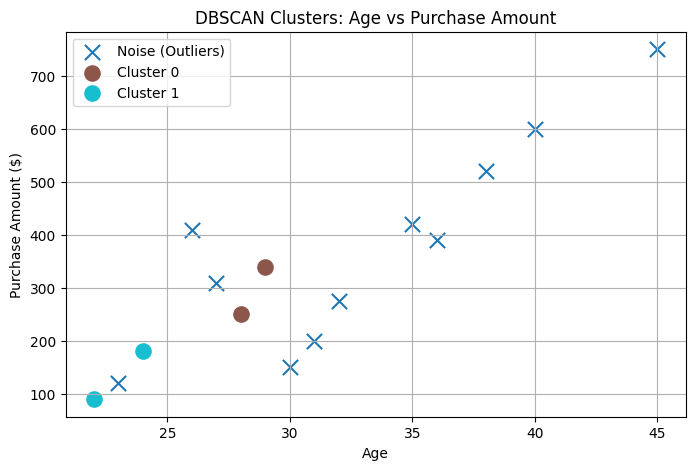

DBSCAN Cluster plot saved ✅

🔍 Full Cluster Comparison:
            Name  Age  Purchase Amount ($)  KMeans_Cluster  HC_Cluster  \
0       Ali Khan   28                  250               0           1   
1     Sara Ahmed   24                  180               1           0   
2      Usman Ali   35                  420               0           1   
3    Ayesha Noor   30                  150               1           0   
4    Hassan Raza   40                  600               2           2   
5   Fatima Zahra   27                  310               1           0   
6    Bilal Ahmed   32                  275               0           1   
7     Hina Malik   22                   90               1           0   
8    Omar Sheikh   29                  340               0           1   
9     Zainab Ali   26                  410               1           0   
10     Saad Khan   38                  520               0           1   
11   Noor Fatima   31                  200              

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# --- Step 1: Find Optimal Epsilon using K-Distance Graph ---
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, 1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph (Find Optimal Epsilon)')
plt.xlabel('Data Points (sorted)')
plt.ylabel('Distance to 2nd Nearest Neighbor')
plt.grid(True)
plt.savefig('dbscan_kdistance.png', dpi=150)
plt.show()
print("K-Distance graph saved ✅")
print("👉 Look at the 'elbow point' in the graph — that is your best epsilon value")

# --- Step 2: Apply DBSCAN ---
eps_value = 1.0       # Adjust based on K-Distance graph elbow
min_samples = 2       # Minimum points to form a cluster

db = DBSCAN(eps=eps_value, min_samples=min_samples)
df['DBSCAN_Cluster'] = db.fit_predict(X_scaled)

# --- Step 3: Results Summary ---
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = list(df['DBSCAN_Cluster']).count(-1)

print(f"\n📊 DBSCAN Results:")
print(f"   ✅ Number of Clusters Found : {n_clusters}")
print(f"   ⚠️  Noise Points (Outliers)  : {n_noise}")

# Silhouette Score (only if more than 1 cluster found)
if n_clusters > 1:
    mask = df['DBSCAN_Cluster'] != -1
    score = silhouette_score(X_scaled[mask], df['DBSCAN_Cluster'][mask])
    print(f"   📈 Silhouette Score         : {score:.4f}")
else:
    print("   ⚠️  Not enough clusters for Silhouette Score — try adjusting eps value")

# --- Step 4: Cluster Summary ---
print("\n📋 DBSCAN Cluster Summary (-1 = Noise/Outlier):")
print(df.groupby('DBSCAN_Cluster')[['Age', 'Purchase Amount ($)', 'Days Since Purchase']].mean().round(2))

# --- Step 5: Visualize DBSCAN Clusters ---
plt.figure(figsize=(8, 5))

unique_labels = sorted(df['DBSCAN_Cluster'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    subset = df[df['DBSCAN_Cluster'] == label]
    point_label = f'Noise (Outliers)' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(subset['Age'], subset['Purchase Amount ($)'],
                label=point_label, s=120, color=color, marker=marker)

plt.title('DBSCAN Clusters: Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount ($)')
plt.legend()
plt.grid(True)
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()
print("DBSCAN Cluster plot saved ✅")

# --- Step 6: Full Comparison Table ---
print("\n🔍 Full Cluster Comparison:")
print(df[['Name', 'Age', 'Purchase Amount ($)', 'KMeans_Cluster', 'HC_Cluster', 'DBSCAN_Cluster']])

print("\nDBSCAN Clustering Complete! ✅")

📊 Explained Variance per Component:
   PC1: 67.47%  |  Cumulative: 67.47%
   PC2: 21.99%  |  Cumulative: 89.46%
   PC3: 6.51%  |  Cumulative: 95.97%
   PC4: 2.17%  |  Cumulative: 98.14%
   PC5: 1.86%  |  Cumulative: 100.00%


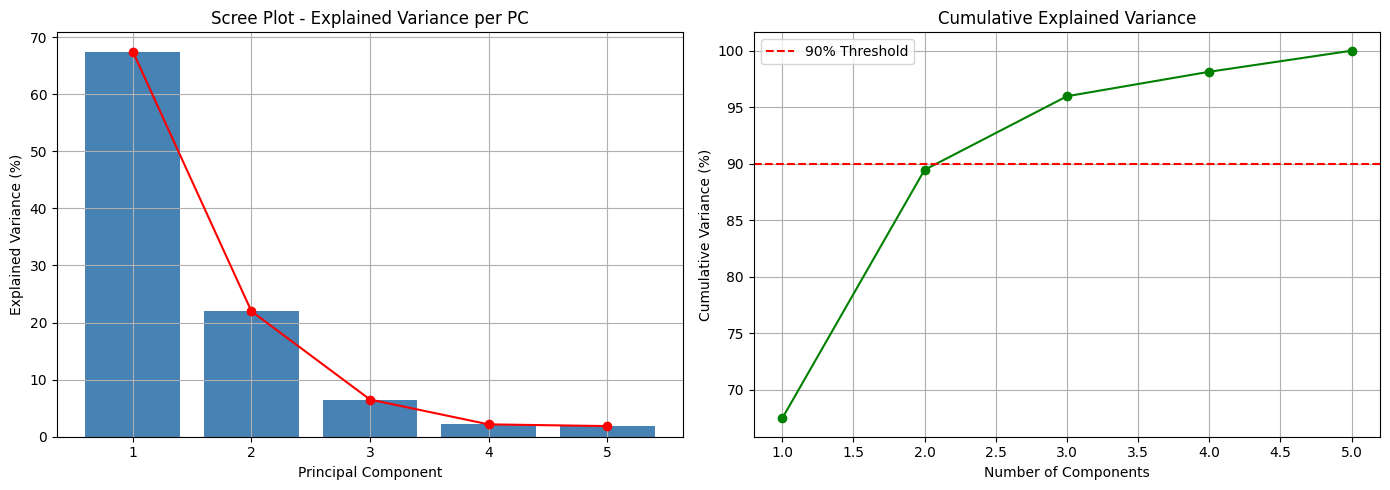

Scree plot saved ✅

✅ Variance captured by 2 components: 89.46%


C:\Users\USER\AppData\Local\Temp\ipykernel_10716\372789928.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique))


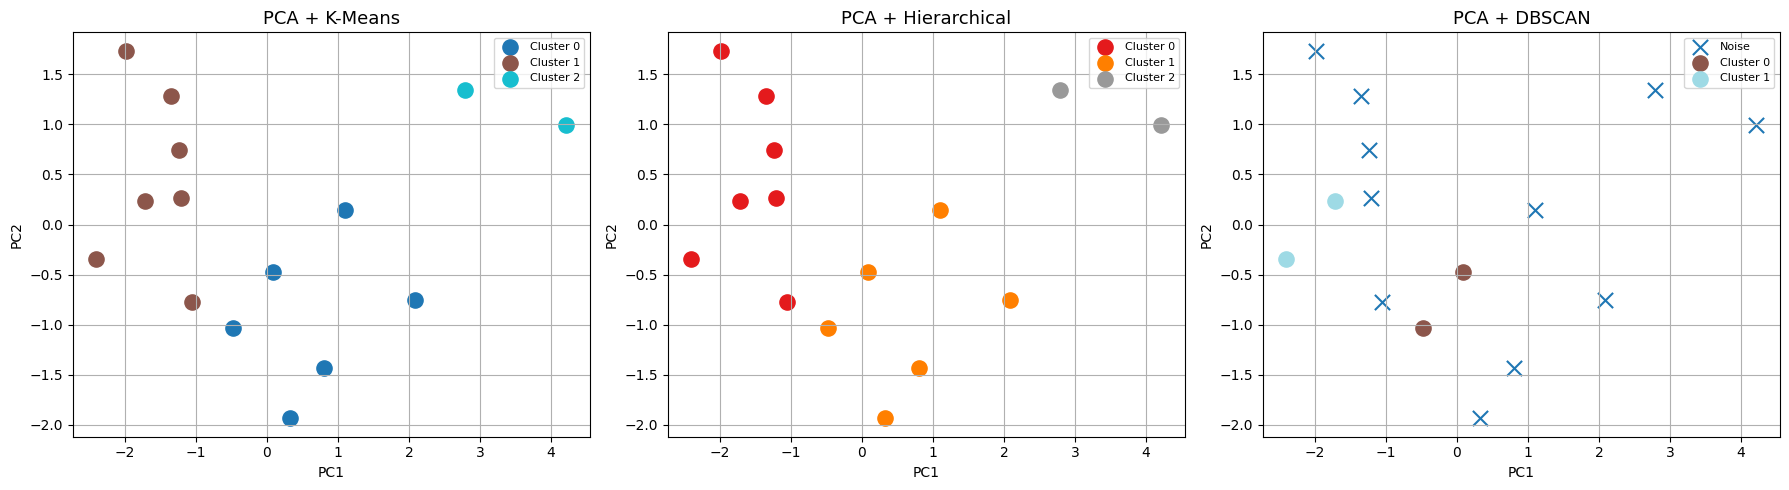

PCA comparison plot saved ✅

📋 PCA Feature Loadings (contribution of each feature):
                       PC1    PC2
Age                  0.524  0.047
Gender               0.433 -0.382
City                 0.092  0.918
Purchase Amount      0.512  0.014
Days Since Purchase  0.517  0.095

🏁 FINAL RESULTS SUMMARY:
        Name  Age  Purchase Amount ($)  KMeans_Cluster  HC_Cluster  DBSCAN_Cluster       PC1       PC2
    Ali Khan   28                  250               0           1               0 -0.468849 -1.029687
  Sara Ahmed   24                  180               1           0               1 -1.719428  0.232940
   Usman Ali   35                  420               0           1              -1  0.809672 -1.429323
 Ayesha Noor   30                  150               1           0              -1 -1.349013  1.278162
 Hassan Raza   40                  600               2           2              -1  2.790776  1.341944
Fatima Zahra   27                  310               1           0  

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd

# --- Step 1: Apply PCA (Full Components) ---
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained Variance
explained_variance = pca_full.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

print("📊 Explained Variance per Component:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"   PC{i+1}: {ev:.2f}%  |  Cumulative: {cv:.2f}%")

# --- Step 2: Scree Plot ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance)+1), explained_variance, color='steelblue')
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', color='red')
plt.title('Scree Plot - Explained Variance per PC')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='green')
plt.axhline(y=90, color='red', linestyle='--', label='90% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150)
plt.show()
print("Scree plot saved ✅")

# --- Step 3: Reduce to 2D for Visualization ---
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df['PC1'] = X_pca_2d[:, 0]
df['PC2'] = X_pca_2d[:, 1]

print(f"\n✅ Variance captured by 2 components: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# --- Step 4: PCA 2D Plot colored by each clustering method ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_cols  = ['KMeans_Cluster', 'HC_Cluster', 'DBSCAN_Cluster']
titles        = ['PCA + K-Means', 'PCA + Hierarchical', 'PCA + DBSCAN']
cmaps         = ['tab10', 'Set1', 'tab20']

for ax, col, title, cmap in zip(axes, cluster_cols, titles, cmaps):
    labels = df[col].values
    unique = sorted(set(labels))
    colors = plt.cm.get_cmap(cmap, len(unique))
    for i, label in enumerate(unique):
        mask = labels == label
        point_label = 'Noise' if label == -1 else f'Cluster {label}'
        marker = 'x' if label == -1 else 'o'
        ax.scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
                   label=point_label, s=120, color=colors(i), marker=marker)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('pca_all_clusters.png', dpi=150)
plt.show()
print("PCA comparison plot saved ✅")

# --- Step 5: PCA Feature Loadings ---
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=['Age', 'Gender', 'City', 'Purchase Amount', 'Days Since Purchase'],
    columns=['PC1', 'PC2']
).round(3)

print("\n📋 PCA Feature Loadings (contribution of each feature):")
print(loadings)

# --- Step 6: Final Summary Table ---
print("\n🏁 FINAL RESULTS SUMMARY:")
print(df[['Name', 'Age', 'Purchase Amount ($)',
          'KMeans_Cluster', 'HC_Cluster', 'DBSCAN_Cluster',
          'PC1', 'PC2']].to_string(index=False))

print("\n🎉 All 5 Parts Complete! Unsupervised Learning Project Done ✅")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ─────────────────────────────────────────
# 1. SILHOUETTE | DAVIES-BOULDIN | CALINSKI-HARABASZ
# ─────────────────────────────────────────

models = {
    'K-Means':       df['KMeans_Cluster'],
    'Hierarchical':  df['HC_Cluster'],
    'DBSCAN':        df['DBSCAN_Cluster']
}

print("=" * 65)
print(f"{'Model':<18} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>18}")
print("=" * 65)

metrics = {}
for name, labels in models.items():
    mask = labels != -1   # exclude DBSCAN noise
    X_clean = X_scaled[mask]
    y_clean = labels[mask]

    if len(set(y_clean)) < 2:
        print(f"{name:<18} {'N/A':>12} {'N/A':>16} {'N/A':>18}")

Model                Silhouette   Davies-Bouldin  Calinski-Harabasz
